# 02. Cleaning the Cafe Dataset

This notebook turns the raw Google Places cafe export into a clean analysis ready file ('cafes_clean.csv'). This dataset is the target variable source only - It is never used to build predictor features to avoid circularity see decision_log.md.

Cleaning steps: Select relevant columns --> Filter cafes --> remove permanently closed outlets --> remove duplicates --> flag popular cafes. Row counts are printed after each step.


In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

RAW = Path("c:\\Users\\cynth\\Downloads\\berlin-cafe-thesis\\berlin-cafe-thesis\\data\\raw\\berlin_cafes.csv")
OUT = Path("c:\\Users\\cynth\\Downloads\\berlin-cafe-thesis\\berlin-cafe-thesis\\data\\processed\\cafes_clean.csv")

In [2]:
df = pd.read_csv(RAW, low_memory=False)
print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(list(df.columns))
df.head(3)

Raw dataset: 4,378 rows × 176 columns
['title', 'sub_title', 'category_name', 'description', 'address', 'located_in', 'neighborhood', 'street', 'city', 'postal_code', 'state', 'country_code', 'menu', 'plus_code', 'website', 'phone', 'price', 'place_id', 'url', 'search_page_url', 'search_string', 'categories', 'image_categories', 'order_by_tabelog', 'order_by_opentable', 'opening_hours_mon', 'opening_hours_tue', 'opening_hours_wed', 'opening_hours_thu', 'opening_hours_fri', 'opening_hours_sat', 'opening_hours_sun', 'hotel_stars', 'total_score', 'location_lat', 'location_lng', 'rank', 'images_count', 'reviews_count', 'reviews_distribution_one_star', 'reviews_distribution_two_star', 'reviews_distribution_three_star', 'reviews_distribution_four_star', 'reviews_distribution_five_star', 'is_advertisement', 'temporarily_closed', 'permanently_closed', 'claim_this_business', 'takeaway', 'in_store_shopping', 'dine_in', 'delivery', 'takeout', 'same_day_delivery', 'no_contact_delivery', 'curbside_

,title,sub_title,category_name,description,address,located_in,neighborhood,street,city,postal_code,...,review0_text,review0_text_translated,review0_visited_in,review0_likes_count,review0_reviewer_number_of_reviews,review0_stars,reviews,popular_times_histogram,scraped_at_timestamp,scraped_at
0,Bubble Tea Bobba,NaN,Cafe,NaN,"Gontardstraße 11/4th floor, 10178 Berlin, Germany",NaN,Gontardstraße 11/4th floor,Gontardstraße 11/4th floor,Berlin,10178.0,...,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,2023-01-16 09:36:00.293,2023-01-16
1,Colourful ChocoWorld Berlin,NaN,Cafe,NaN,"Franz. Str. 24, 10117 Berlin, Germany",Galeries Lafayette,Franz. Str. 24,Franz. Str. 24,Berlin,10117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,2023-01-16 10:12:00.435,2023-01-16
2,Café Klatsch,NaN,Cafe,NaN,"Kaiserin-Augusta-Straße 78, 12103 Berlin, Germany",NaN,Kaiserin-Augusta-Straße 78,Kaiserin-Augusta-Straße 78,Berlin,12103.0,...,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,2023-01-16 11:19:58.406,2023-01-16


## Step 1: Select and Rename the relevant cols
Out of 176 scraped cols, only 12 are relevant: Title, coordinates, the two popularity signals (rating and review count), and the status flags.

In [3]:
KEEP_COLS = ["place_id", "title", "category_name", "location_lat", "location_lng",
             "total_score", "reviews_count", "postal_code", "city",
             "permanently_closed", "temporarily_closed", "scraped_at"]

cafes = df[KEEP_COLS].rename(columns={"total_score": "rating",
                                      "reviews_count": "n_reviews"})

print(f"Kept {cafes.shape[1]} columns from {df.shape[1]}")
cafes.head(3)

Kept 12 columns from 176


,place_id,title,category_name,location_lat,location_lng,rating,n_reviews,postal_code,city,permanently_closed,temporarily_closed,scraped_at
0,ChIJYWZYyONPqEcRFpFCPbCW-4s,Bubble Tea Bobba,Cafe,52.520835,13.411318,3.0,4,10178.0,Berlin,False,False,2023-01-16
1,ChIJk3pC4dpRqEcRWt6TqP_HcAc,Colourful ChocoWorld Berlin,Cafe,52.514605,13.390504,4.1,29,10117.0,Berlin,False,False,2023-01-16
2,ChIJTf9jUv9PqEcRNnubfMJHZNU,Café Klatsch,Cafe,52.459233,13.383816,NaN,0,12103.0,Berlin,False,False,2023-01-16


## Step 2: Inspect data quality

Before filtering, check for missing values and inspect the category composition. This provides the evidence base for cleaning


In [4]:
print("Missing values on key columns:")
print(cafes[["rating", "n_reviews", "location_lat", "city"]].isna().sum(), "\n") # check for blanks, count blanks

print(f"Total number of unique categories: {cafes['category_name'].nunique()}")
print("Top venue categories:")
print(cafes["category_name"].value_counts().head(30), "\n")

print(f"Permanently closed : {cafes['permanently_closed'].sum():,}")
print(f"Temporarily closed : {cafes['temporarily_closed'].sum():,}")

Missing values on key columns:
rating          395
n_reviews         0
location_lat      0
city              5
dtype: int64 

Total number of unique categories: 228
Top venue categories:
category_name
Cafe                        2709
Bakery                       307
Restaurant                   168
Gas station                  141
Bar                           91
Ice cream shop                86
Coffee shop                   73
Internet cafe                 62
Breakfast restaurant          41
Bistro                        29
Hookah bar                    29
Italian restaurant            28
German restaurant             18
Vegetarian cafe and deli      18
Art cafe                      17
Donut shop                    17
Coffee roasters               16
Pastry shop                   16
Kiosk                         16
Cocktail bar                  15
Brunch restaurant             15
Pub                           12
Vegan restaurant              11
Restaurant or cafe             9
Pizza r

## Step 3: Filter to cafes 
The dataset includes many non-cafe outlets (bakeries, restaurants, bars, gas stations etc) A cafe is defined as a coffee-first venue however we will include bakeries, pastry and donut shops since they reflect the German Bäckerei with seating culture. excluded: internet cafes, icecream shops, delis, bars and other non cafe categories. see decision_log.md 

In [12]:
KEEP_CATEGORIES = [
    "Cafe", "Coffee shop", "Coffee roasters", "Coffee store", "Espresso bar",
    "Art cafe", "Chocolate cafe", "Children's cafe", "Vegetarian cafe and deli",
    "Restaurant or cafe", "Cafeteria",
    # bakery / pastry / donut (the Moderate add-on)
    "Bakery", "Pastry shop", "Patisserie", "Donut shop", "Cake shop",
]

before = len(cafes)
cafes = cafes[cafes["category_name"].isin(KEEP_CATEGORIES)]
print(f"cafe filter: {before:,} → {len(cafes):,}  ({len(cafes) - before:,})")

cafe filter: 2,434 → 2,434  (0)


## Step 4: Remove Permanently closed outlets

Permanently closed cafes no longer represent real supply hence - removed. Temporarily closed cafes are kept but remain flagged. 

In [6]:
before = len(cafes)
cafes = cafes[~cafes["permanently_closed"].astype(bool)]
print(f"Drop permanently closed: {before:,} → {len(cafes):,}  ({len(cafes) - before:,})")
print(f"Temporarily closed still in set (kept, flagged): "
      f"{cafes['temporarily_closed'].astype(bool).sum()}")

Drop permanently closed: 3,222 → 2,435  (-787)
Temporarily closed still in set (kept, flagged): 118


## Step 5: Remove Duplicates.

Deduplicate'place_id' and check on title + coordinates in case the same outlet was scraped under two separate IDs

In [ ]:
## Step 3: Filter to cafés
before = len(cafes)
cafes = cafes[cafes["category_name"].isin(KEEP_CATEGORIES)]
print(f"café filter: {before:,} → {len(cafes):,}  ({len(cafes) - before:,})")

Drop duplicates: 2,435 → 2,434  (-1)



Cafes are not filtered to the Berlin Boundary here since each cafe will be assigned to a H3 hexagon in notebook 03 and any cafe outside the berlin hexagon grid will be dropped.

## Step 6: Create 'popular cafes' flag

Cafe Popularity will be used as a proxy since features like revenue and footfall are not publicly available.The initial assumption for the threshold is rating ≥ 4.2, ≥ 100
reviews but we first need to check the distribution to see if the cut-offs are sensible. However, full eda of the target variable is done separately in notebook 04

In [8]:
cafes["is_popular_prov"] = ((cafes["rating"] >= 4.2) &
                            (cafes["n_reviews"] >= 100)).astype(int)

print(f"Popular cafés (provisional): {cafes['is_popular_prov'].sum():,} "
      f"of {len(cafes):,}  ({cafes['is_popular_prov'].mean()*100:.0f}%)")

Popular cafés (provisional): 923 of 2,434  (38%)


In [9]:
print("RATING distribution:")
print(cafes["rating"].describe(), "\n")

print("REVIEW COUNT distribution:")
print(cafes["n_reviews"].describe(), "\n")

# where do our two thresholds sit?
print(f"Cafés with rating ≥ 4.2 : {(cafes['rating'] >= 4.2).sum():,} "
      f"({(cafes['rating'] >= 4.2).mean()*100:.0f}%)")
print(f"Cafés with ≥ 100 reviews: {(cafes['n_reviews'] >= 100).sum():,} "
      f"({(cafes['n_reviews'] >= 100).mean()*100:.0f}%)")

RATING distribution:
count    2251.000000
mean        4.312883
std         0.602715
min         1.000000
25%         4.100000
50%         4.500000
75%         4.700000
max         5.000000
Name: rating, dtype: float64 

REVIEW COUNT distribution:
count    2434.000000
mean      244.544782
std       419.348947
min         0.000000
25%        20.000000
50%        96.500000
75%       288.000000
max      5606.000000
Name: n_reviews, dtype: float64 

Cafés with rating ≥ 4.2 : 1,626 (67%)
Cafés with ≥ 100 reviews: 1,204 (49%)


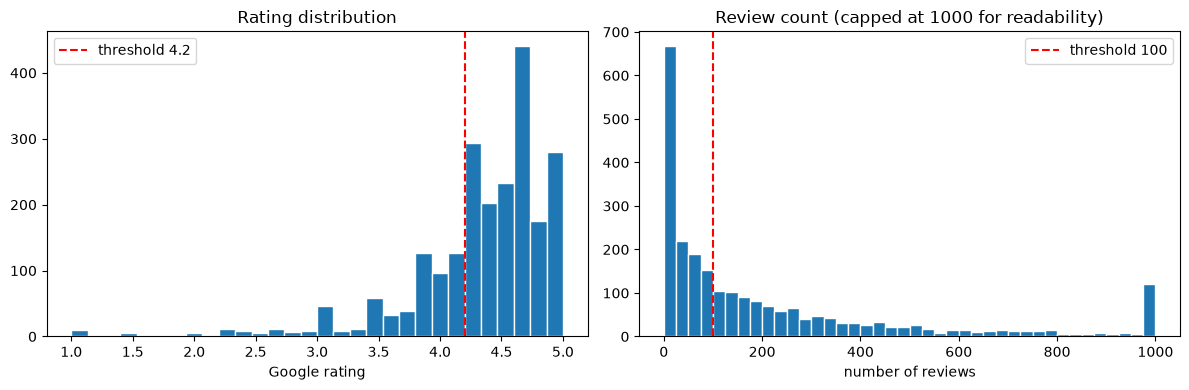

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(cafes["rating"].dropna(), bins=30, edgecolor="white")
ax1.axvline(4.2, color="red", linestyle="--", label="threshold 4.2")
ax1.set_title("Rating distribution"); ax1.set_xlabel("Google rating"); ax1.legend()

ax2.hist(cafes["n_reviews"].clip(upper=1000), bins=40, edgecolor="white")
ax2.axvline(100, color="red", linestyle="--", label="threshold 100")
ax2.set_title("Review count (capped at 1000 for readability)")
ax2.set_xlabel("number of reviews"); ax2.legend()

plt.tight_layout(); plt.show()

## Step 7 Validate and Save 

Before saving, three assertions confirm the cleaning done No duplicate outlets, no missing coordinates and no permanently closed cafes. the cleaned ds is saved to `data/processed/cafes_clean.csv`.

In [11]:
# tripwires: each must be true, or the notebook stops here
assert cafes["place_id"].is_unique, "Duplicate place_ids remain"
assert cafes["location_lat"].notna().all(), "Some cafés are missing coordinates"
assert not cafes["permanently_closed"].astype(bool).any(), "Permanently closed cafés remain"

cafes.to_csv(OUT, index=False)
print(f"Saved {len(cafes):,} cafés → {OUT}")
print(f"   of which {cafes['is_popular_prov'].sum():,} are provisionally popular")

Saved 2,434 cafés → c:\Users\cynth\Downloads\berlin-cafe-thesis\berlin-cafe-thesis\data\processed\cafes_clean.csv
   of which 923 are provisionally popular
